# Figures 9,11,12,13

By: Morgan Handojo
In the following order: 13, 12, 9, 11

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib_venn import venn2
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

In [2]:
profiles = pd.read_csv("OmicsProfiles.csv")
muts = pd.read_csv("OmicsSomaticMutations.csv")
expression = pd.read_csv("OmicsExpressionTPMLogp1HumanProteinCodingGenes.csv")
model = pd.read_csv("Model.csv")

/tmp/ipykernel_2051798/2578315513.py:2: DtypeWarning: Columns (22,50,56,57,58,59,61) have mixed types. Specify dtype option on import or set low_memory=False.
  muts = pd.read_csv("OmicsSomaticMutations.csv")


Important Genes:
    - 'COL9A2 (1298)'
    - 'SNAPC1 (6617)'
    - 'FXYD3 (5349)'

In [3]:
df = expression[['ModelID', 'FXYD3 (5349)']].merge(profiles[['ModelID', 'Lineage']], on="ModelID")
df = df[~df['Lineage'].isin(['nan','Other','Ampulla of Vater','Hair','Soft Tissue','Fibroblast', 'Embryonal'])]

In [4]:
df = expression.merge(profiles[['ModelID', 'Lineage']], on="ModelID")
df = df.drop(columns=['Unnamed: 0','SequencingID','ModelID','IsDefaultEntryForModel','ModelConditionID','IsDefaultEntryForMC'])

In [5]:
top_50_SHAP = ["COL9A2 (1298)","SNAPC1 (6617)","VMP1 (81671)","ANO2 (57101)","CDH3 (1001)","TNS1 (7145)","FXYD3 (5349)","SBNO2 (22904)","KDM5D (8284)","GNA15 (2769)","GCKR (2646)","NRXN3 (9369)","GDI2 (2665)","MPND (84954)","ISL1 (3670)","BCAP29 (55973)","TLE2 (7089)","DSG2 (1829)","KCNH2 (3757)","STAG3 (10734)","RTF2 (51507)","MTMR1 (8776)","TMEM176A (55365)","CMTM1 (113540)","RDH8 (50700)","RCN1 (5954)","WNT11 (7481)","U2AF2 (11338)","TRIB2 (28951)","OXCT1 (5019)","FUT8 (2530)","ZNF532 (55205)","KITLG (4254)","DNAJB11 (51726)","GRAMD4 (23151)","REXO2 (25996)","ACACB (32)","RUNX3 (864)","STXBP2 (6813)","DPF1 (8193)","ANK1 (286)","RFX3 (5991)","ADGRL1 (22859)","SPTB (6710)","SAMD4A (23034)","NUP160 (23279)","PAK3 (5063)","RPS6KA2 (6196)","FAT1 (2195)","MRPL22 (29093)"]
SHAP_df = df[top_50_SHAP]

In [6]:
df = expression.merge(profiles[['ModelID', 'Lineage']], on="ModelID")
df = df.drop(columns=['Unnamed: 0','SequencingID','ModelID','IsDefaultEntryForModel','ModelConditionID','IsDefaultEntryForMC'])

In [7]:
med = df.groupby('Lineage').mean()
column_variances = med.var()
sorted_variances = column_variances.sort_values(ascending=False)

# Figure 13

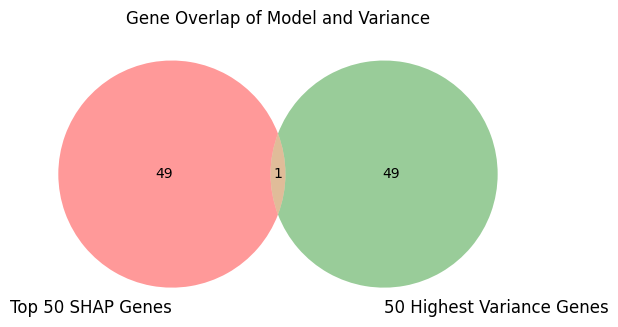

In [8]:
venn2([set(top_50_SHAP), set(sorted_variances.index[:50])], set_labels=('Top 50 SHAP Genes', '50 Highest Variance Genes'))
plt.title("Gene Overlap of Model and Variance")
plt.show()

# Figure 12

In [9]:
X = StandardScaler().fit_transform(SHAP_df)
X_pca = PCA(n_components=33).fit_transform(X)

X_tsne = TSNE(n_components=2, perplexity=30).fit_transform(X_pca)
df['TSNE1'] = X_tsne[:, 0]
df['TSNE2'] = X_tsne[:, 1]

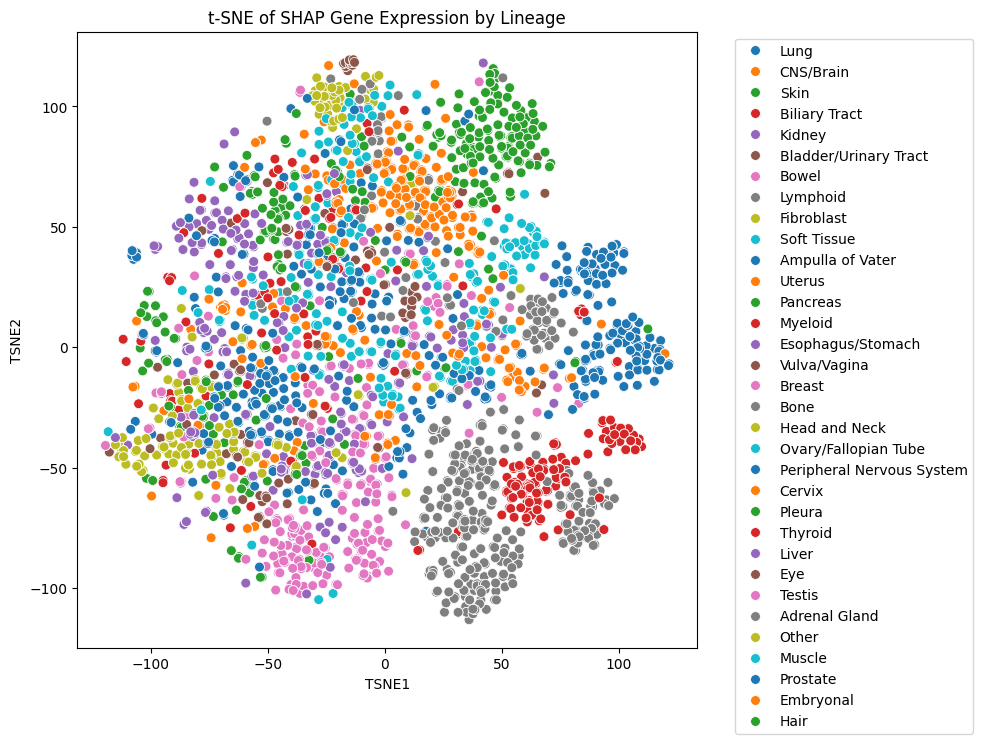

In [10]:
plt.figure(figsize=(8,8))
sns.scatterplot(
    x='TSNE1',
    y='TSNE2',
    data=df,
    hue='Lineage',
    palette='tab10',
    s=50
)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title("t-SNE of SHAP Gene Expression by Lineage")
plt.show()

# Figure 9

In [11]:
# removing these for visualization because the counts are too low
df = df[~df['Lineage'].isin(['nan','Other','Ampulla of Vater','Hair','Soft Tissue','Fibroblast', 'Embryonal'])]

/opt/jupyterhub/pyvenv/lib/python3.12/site-packages/seaborn/categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


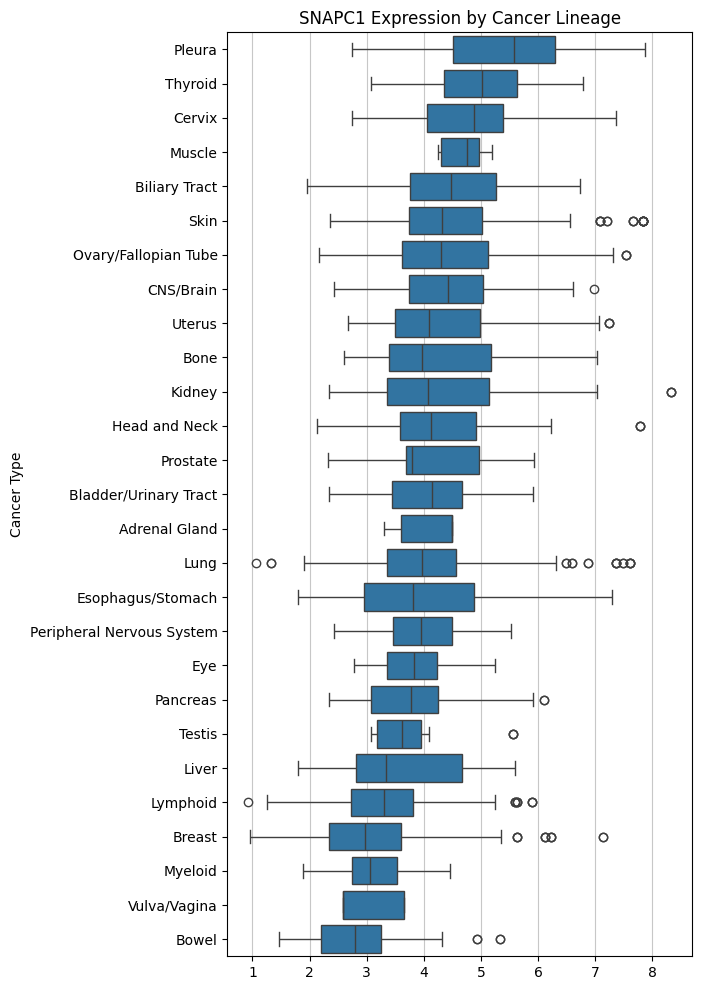

In [12]:
order = df.groupby('Lineage')['SNAPC1 (6617)'].mean().sort_values(ascending=False).index
fig, ax = plt.subplots(1, figsize=(6, 12), sharex=True)


sns.boxplot(
    x='SNAPC1 (6617)', 
    y='Lineage', 
    data=df, 
    order=order
)
ax.set_title('SNAPC1 Expression by Cancer Lineage')
ax.set_xlabel('')
ax.set_ylabel('Cancer Type')
ax.grid(axis='x', linestyle='-', alpha=0.7)

# Figure 11

/opt/jupyterhub/pyvenv/lib/python3.12/site-packages/seaborn/categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


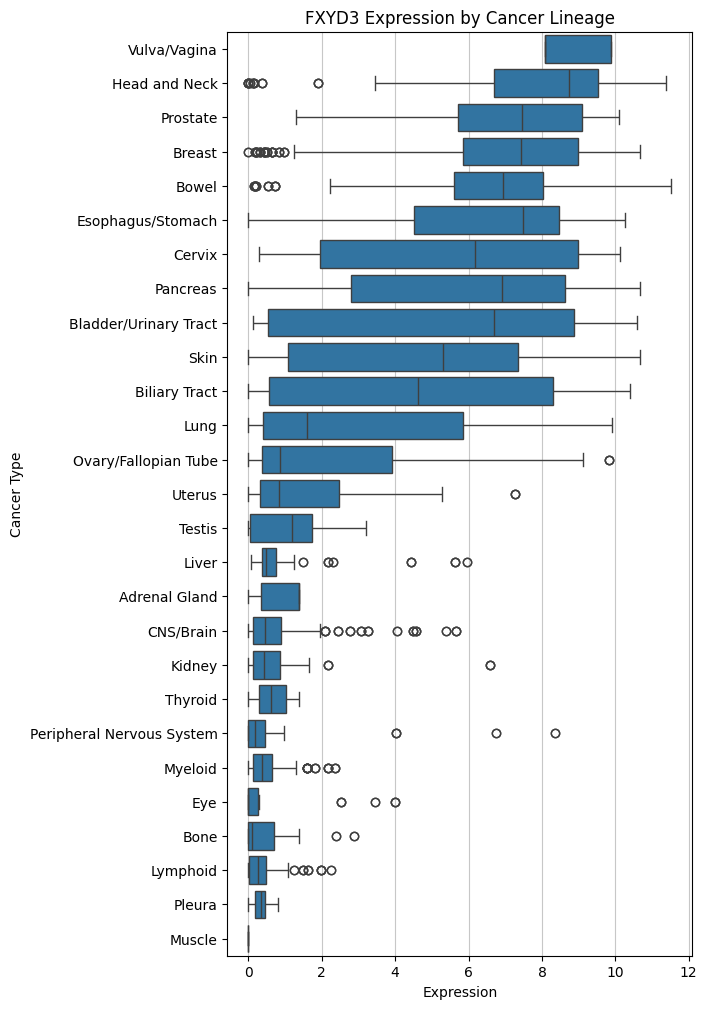

In [13]:
order = df.groupby('Lineage')['FXYD3 (5349)'].mean().sort_values(ascending=False).index

fig, ax = plt.subplots(1, figsize=(6, 12), sharex=True)

sns.boxplot(
    x='FXYD3 (5349)', 
    y='Lineage', 
    data=df, 
    order=order
)
ax.set_title('FXYD3 Expression by Cancer Lineage')
ax.set_xlabel('Expression')
ax.set_ylabel('Cancer Type')
ax.grid(axis='x', linestyle='-', alpha=0.7)
